In [2]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import(
    r2_score, mean_absolute_error, mean_squared_error
)
from sklearn.model_selection import(
    train_test_split, cross_val_score
)

In [3]:
df = pd.read_csv("../data/engineered_car_data.csv")

df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Mileage_per_Year,Log_Selling_Price,Log_Kms_Driven,Age_Group
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,2250.000000,1.208960,10.203592,Old
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,3307.692308,1.558145,10.668955,Old
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,766.666667,1.981001,8.839277,Medium
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,346.666667,1.047319,8.556414,Old
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,3537.500000,1.526056,10.656082,Old


In [4]:
df["Age_Group"] = df["Age_Group"].fillna("Old")

df = pd.get_dummies(
    df,
    columns=["Fuel_Type","Seller_Type","Transmission","Age_Group"],
    drop_first=True
)

In [5]:
X = df.drop(
    ["Selling_Price", "Log_Selling_Price"],
    axis=1
)

y = df["Selling_Price"]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
elastic = joblib.load(
    "../src/best_car_price_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [8]:
train_pred=elastic.predict(X_train)
test_pred=elastic.predict(X_test)
print("R2 Score on Train Set:",r2_score(y_train,train_pred))
print("R2 Score on Test Set:",r2_score(y_test,test_pred))

R2 Score on Train Set: 0.880324225411258
R2 Score on Test Set: 0.8518148937718757


In [9]:
n = len(y_test)
p = X_test.shape[1]

r2 = r2_score(y_test, test_pred)

adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print("Adjusted R2:", adj_r2)

Adjusted R2: 0.8147686172148446


In [10]:
cv_scores = cross_val_score(
    elastic,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

CV Scores: [   0.88507815    0.74750566 -100.70613477    0.61538982    0.84743606]
Average CV Score: -19.522145018476778


In [11]:
print(cv_scores)
print("Min Score:", cv_scores.min())
print("Max Score:", cv_scores.max())

[   0.88507815    0.74750566 -100.70613477    0.61538982    0.84743606]
Min Score: -100.70613477085678
Max Score: 0.885078145070251


In [12]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    elastic,
    X,
    y,
    cv=kf,
    scoring='r2'
)

print("CV Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

CV Scores: [0.85181489 0.69022305 0.81804866 0.83626562 0.90122111]
Average CV Score: 0.8195146658647889


In [13]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print("Baseline R2 Score:", r2_score(y_test, dummy_pred))
print("Baseline MAE:", mean_absolute_error(y_test, dummy_pred))
print("Baseline MSE:", mean_squared_error(y_test, dummy_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, dummy_pred)))

Baseline R2 Score: -0.00038173746560565824
Baseline MAE: 3.38583674863388
Baseline MSE: 23.044378065943768
Baseline RMSE: 4.800456026873256


In [14]:
from sklearn.inspection import permutation_importance
result =permutation_importance(
    elastic,X_test,y_test,n_repeats=10,random_state=42
)
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean,
})
importance_df = importance_df.sort_values(by="Importance", ascending=False)
print(importance_df)

                   Feature  Importance
1            Present_Price    1.019160
0                     Year    0.057993
4                  Car_Age    0.057932
7         Fuel_Type_Diesel    0.021675
9   Seller_Type_Individual    0.016777
8         Fuel_Type_Petrol    0.013789
10     Transmission_Manual    0.005347
2               Kms_Driven    0.003949
5         Mileage_per_Year    0.000990
11           Age_Group_Old    0.000933
3                    Owner    0.000103
6           Log_Kms_Driven    0.000000


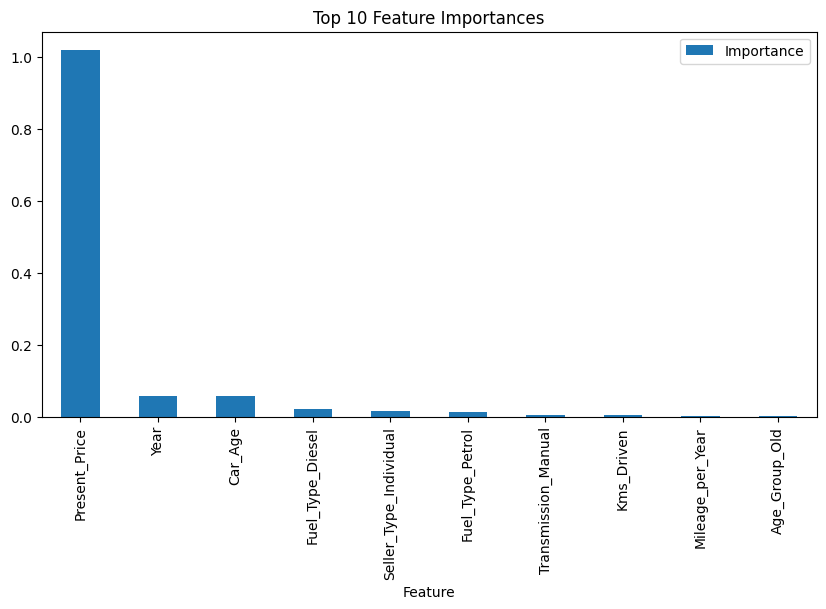

In [15]:
import matplotlib.pyplot as plt

importance_df.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Feature Importances")
plt.show()

In [16]:
evaluation_df = pd.DataFrame({
    "Metric": [
        "Train R2",
        "Test R2",
        "Adjusted R2",
        "CV Mean R2",
        "Baseline R2",
        "MAE",
        "RMSE"
    ],
    "Value": [
        0.8803,
        0.8518,
        0.8148,
        0.8195,
        -0.0004,
        1.2027,
        1.8476
    ]
})

print(evaluation_df)

        Metric   Value
0     Train R2  0.8803
1      Test R2  0.8518
2  Adjusted R2  0.8148
3   CV Mean R2  0.8195
4  Baseline R2 -0.0004
5          MAE  1.2027
6         RMSE  1.8476


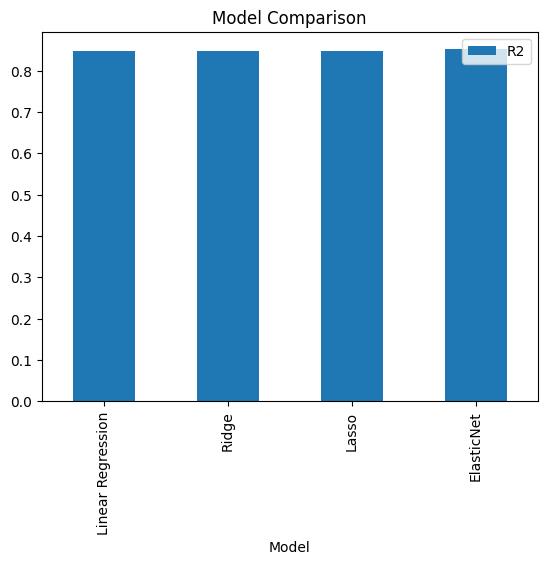

In [17]:
comparison_df = pd.DataFrame({
    "Model":["Linear Regression","Ridge","Lasso","ElasticNet"],
    "R2":[0.8469,0.8485,0.8486,0.8518],
    "MAE":[1.2538,1.2433,1.2115,1.2027],
    "RMSE":[1.8778,1.8681,1.8672,1.8476]
})

comparison_df
comparison_df.plot(x="Model", y="R2", kind="bar")
plt.title("Model Comparison")
plt.show()